# SINDy Basics - Lorenz System

This notebook demonstrates how to use PySINDy to discover governing equations from data.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps

## 1. Generate Lorenz System Data

The Lorenz system:
- dx/dt = σ(y - x)
- dy/dt = x(ρ - z) - y  
- dz/dt = xy - βz

With standard parameters: σ=10, ρ=28, β=8/3

In [4]:
# Lorenz system parameters
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0

def lorenz(t, state):
    x, y, z = state
    return [
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z
    ]

# Initial conditions and time
x0 = [-8, 7, 27]
t_span = (0, 10)
t_eval = np.linspace(0, 10, 1000)

# Solve ODE
sol = solve_ivp(lorenz, t_span, x0, t_eval=t_eval, method='RK45')
X = sol.y.T  # shape: (n_samples, n_features)
t = sol.t

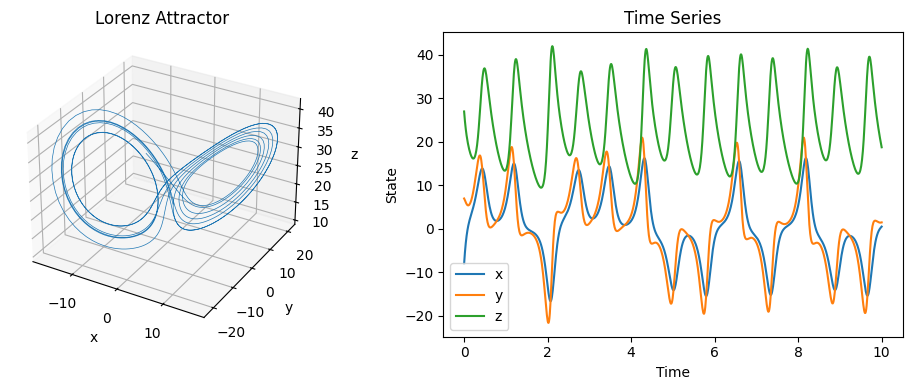

In [5]:
# Plot the Lorenz attractor
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(X[:, 0], X[:, 1], X[:, 2], lw=0.5)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_title('Lorenz Attractor')

ax2 = fig.add_subplot(122)
ax2.plot(t, X)
ax2.set_xlabel('Time')
ax2.set_ylabel('State')
ax2.legend(['x', 'y', 'z'])
ax2.set_title('Time Series')

plt.tight_layout()
plt.show()

## 2. Split Data into Train/Test

For proper model evaluation, we split the data into training and testing sets. 
For time series, we use a temporal split (not random).


In [6]:
# Split data into train/test (70% train, 30% test)
split_idx = int(0.7 * len(X))
X_train = X[:split_idx]
t_train = t[:split_idx]
X_test = X[split_idx:]
t_test = t[split_idx:]

print(f"Training data: {len(X_train)} samples (t: {t_train[0]:.2f} to {t_train[-1]:.2f})")
print(f"Test data: {len(X_test)} samples (t: {t_test[0]:.2f} to {t_test[-1]:.2f})")


Training data: 700 samples (t: 0.00 to 7.00)
Test data: 300 samples (t: 7.01 to 10.00)


## 3. Fit SINDy Model

In [7]:
# !pip install scikit-learn==1.5.2

import sklearn

print(sklearn.__version__)

1.5.2


In [8]:
# Create and fit SINDy model on TRAINING data only
model = ps.SINDy(
    optimizer=ps.STLSQ(threshold=0.1),
    feature_library=ps.PolynomialLibrary(degree=2)
)

model.fit(X_train, t=t_train, feature_names=['x', 'y', 'z'])
print("Discovered equations:")
model.print()

Discovered equations:
(x)' = -9.985 x + 9.984 y
(y)' = 27.653 x + -0.928 y + -0.989 x z
(z)' = -2.660 z + 0.996 x y


## 4. Validate Model on Test Data

Compare SINDy prediction with true data on the test set to evaluate generalization.

Mean absolute error on test set: 0.518095


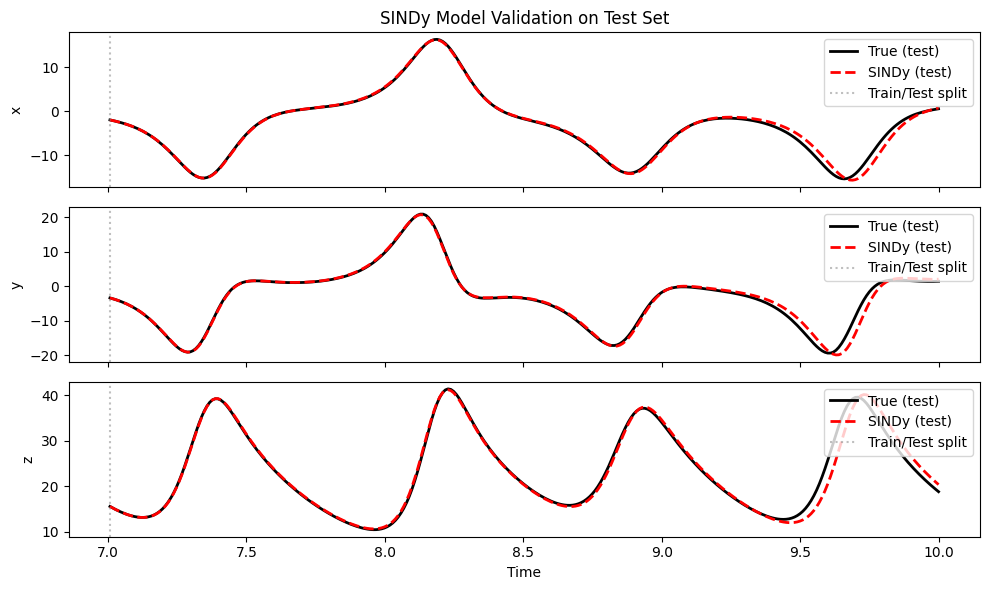

In [12]:
# Simulate using discovered model starting from test set initial condition
x0_test = X_test[0]  # Initial condition for test set
X_sim_test = model.simulate(x0_test, t_test)

# Calculate test error
test_error = np.mean(np.abs(X_test - X_sim_test))
print(f"Mean absolute error on test set: {test_error:.6f}")

# Plot comparison on test set
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

labels = ['x', 'y', 'z']
for i, ax in enumerate(axes):
    ax.plot(t_test, X_test[:, i], 'k', label='True (test)', linewidth=2)
    ax.plot(t_test, X_sim_test[:, i], 'r--', label='SINDy (test)', linewidth=2)
    ax.axvline(t_test[0], color='gray', linestyle=':', alpha=0.5, label='Train/Test split')
    ax.set_ylabel(labels[i])
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time')
axes[0].set_title('SINDy Model Validation on Test Set')
plt.tight_layout()
plt.show()

## 5. Model Coefficients

In [ ]:
# Get coefficients
print("Feature names:", model.get_feature_names())
print("\nCoefficients:")
print(model.coefficients())

Feature names: ['1', 'x', 'y', 'z', 'x^2', 'x y', 'x z', 'y^2', 'y z', 'z^2']

Coefficients:
[[ 0.         -9.98478971  9.9843133   0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.         27.65292887 -0.92813323  0.          0.          0.
  -0.98919143  0.          0.          0.        ]
 [ 0.          0.          0.         -2.66004034  0.          0.99633451
   0.          0.          0.          0.        ]]


## 6. Exercise

Try modifying:
- `threshold` in STLSQ optimizer
- `degree` in PolynomialLibrary
- Add noise to the data
- Change the train/test split ratio

How do these changes affect the discovered equations and test set performance?

In [11]:
# Your experiments here
